# Import Prerequisites

In [1]:
import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [2]:
case_time = pd.read_csv('districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [3]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [4]:
state = "Karnataka"
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
128,2020-04-26,Karnataka,Bagalkote,24,6,1
129,2020-04-26,Karnataka,Ballari,13,5,0
130,2020-04-26,Karnataka,Belagavi,52,6,1
131,2020-04-26,Karnataka,Bengaluru Rural,6,5,0
132,2020-04-26,Karnataka,Bengaluru Urban,129,53,5
...,...,...,...,...,...,...
258161,2021-06-02,Karnataka,Tumakuru,104134,91392,911
258162,2021-06-02,Karnataka,Udupi,59441,53898,331
258163,2021-06-02,Karnataka,Uttara Kannada,45592,40420,583
258164,2021-06-02,Karnataka,Vijayapura,33405,31115,416


In [5]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [6]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [7]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x  

            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
    print("=",end="")
print(" ||")

Preparing chronological district data for year 2020
|| =============================== ||


In [8]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [9]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x 
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
    print("=",end="")
print(" ||")

Preparing chronological district data for year 2021
|| =============================== ||


Trend of Active cases in Bengaluru Urban for the year 2020


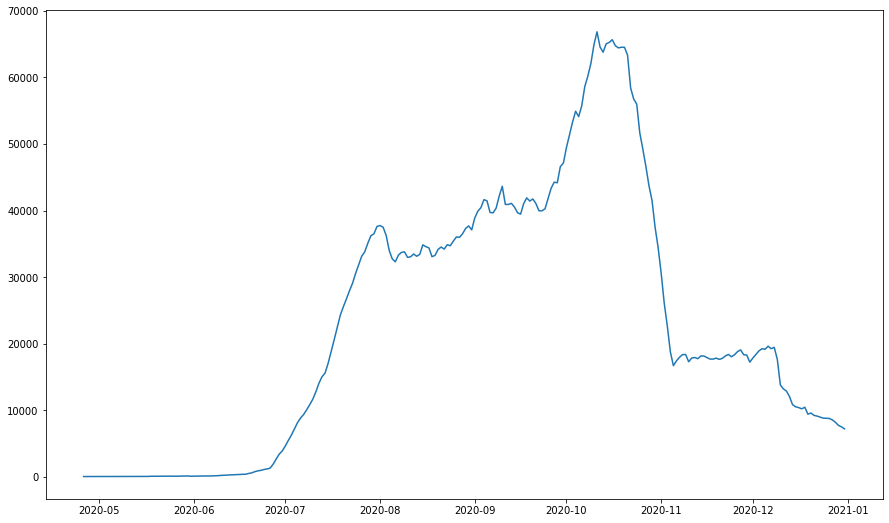

In [10]:
district = 'Bengaluru Urban'
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of Active cases in Bengaluru Urban for the year 2021


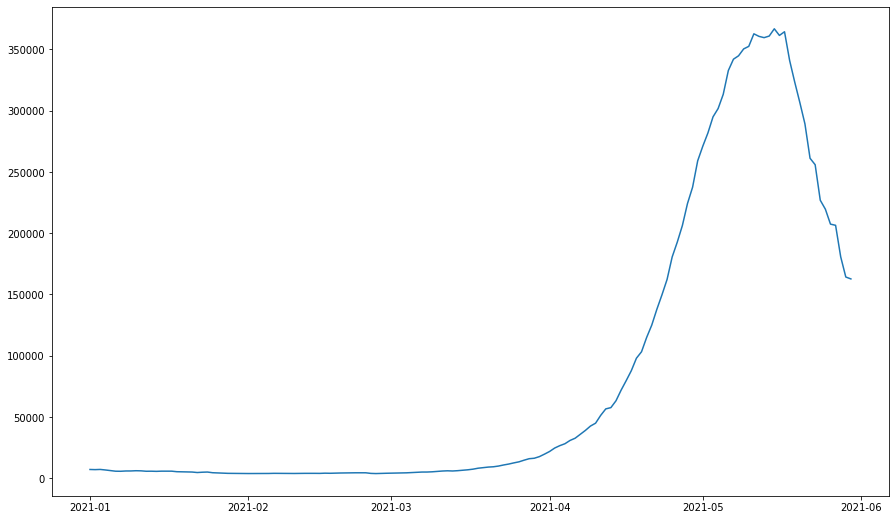

In [11]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of Active cases in",district,"for the year 2021")
plt.plot(bang_data_21)

In [12]:
#Quarter-wise div

quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Bengaluru Urban
            Active
Date              
2020-04-26      71
2020-04-27      72
2020-04-28      68
2020-04-29      68
2020-04-30      75
...            ...
2020-12-27    8576
2020-12-28    8226
2020-12-29    7751
2020-12-30    7535
2020-12-31    7234

[250 rows x 1 columns]
            Active
Date              
2021-01-01    7086
2021-01-02    6965
2021-01-03    7123
2021-01-04    6692
2021-01-05    6148
...            ...
2021-05-26  207358
2021-05-27  206391
2021-05-28  180698
2021-05-29  164183
2021-05-30  162626

[150 rows x 1 columns]


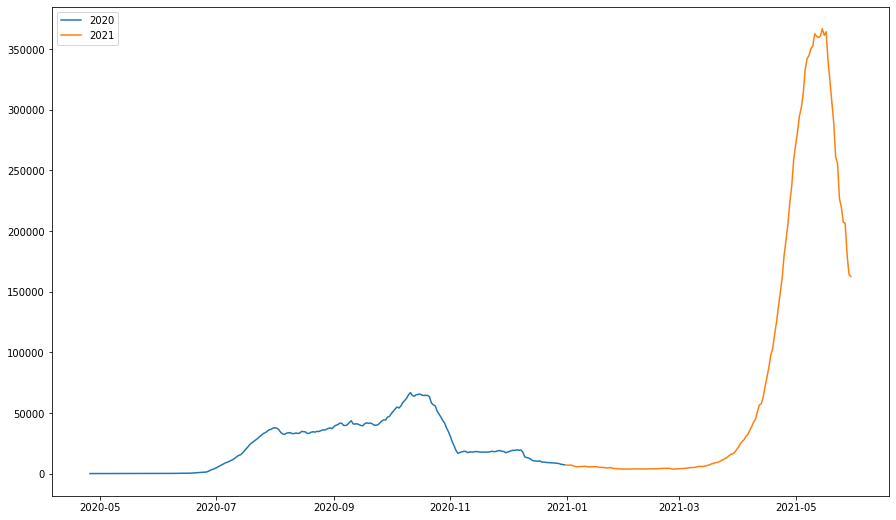

In [13]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# Stationarity check and Transformations

In [14]:
from statsmodels.tsa.stattools import adfuller

(-2.095752955871063, 0.24622578515298266, 7, 242, {'1%': -3.457664132155201, '5%': -2.8735585105960224, '10%': -2.5731749894132916}, 3822.4518654483404)
Non stationary


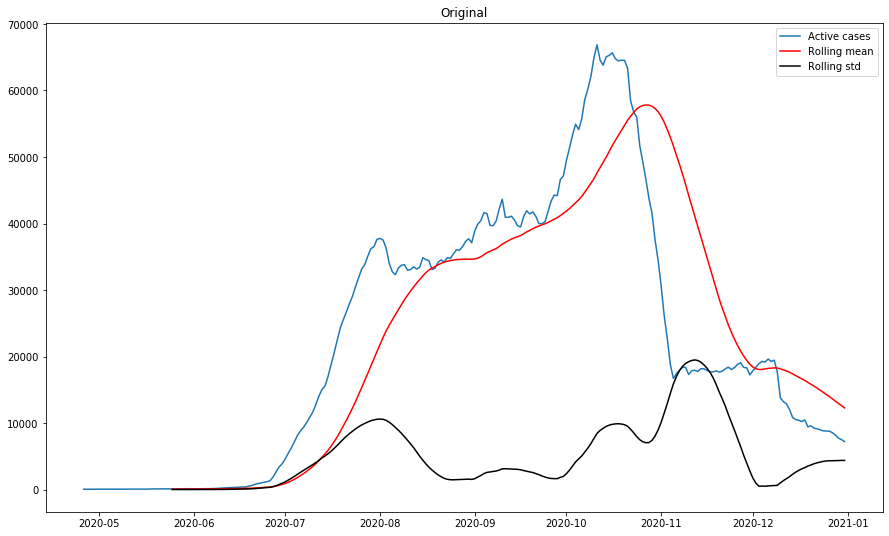

In [15]:
rolmean = bang_data.rolling(window=30).mean()
rolstd = bang_data.rolling(window=30).std()
org = plt.plot(bang_data, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Original')

adftst = adfuller(bang_data['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

In [16]:
# Sqrt to fix non-stationarity
bang_data_sqrt = np.sqrt(bang_data)

# Differencing method
bang_data_second = bang_data_sqrt.diff(1)
bang_data_second = bang_data_second.dropna()

(-3.0344288570950115, 0.031801886327940856, 4, 244, {'1%': -3.457437824930831, '5%': -2.873459364726563, '10%': -2.573122099570008}, 1094.2266225673336)
Stationary


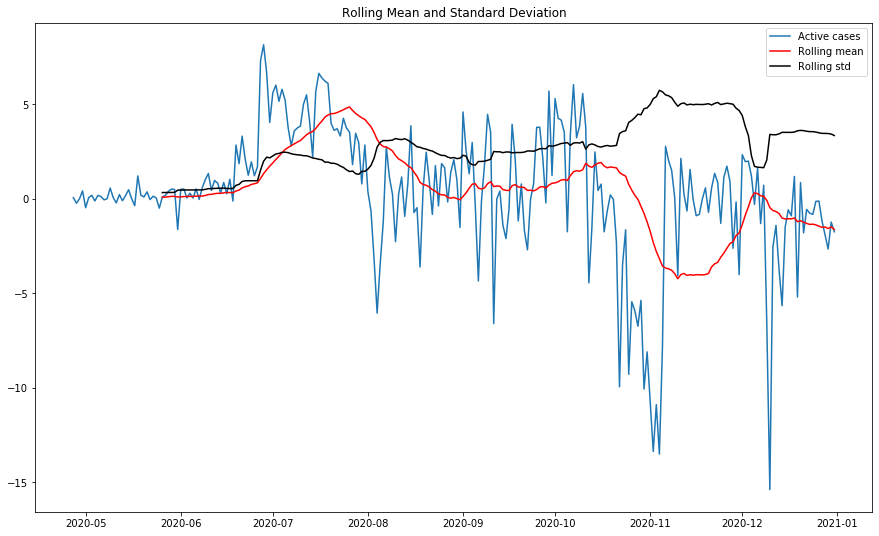

In [17]:
rolmean = bang_data_second.rolling(window=30).mean()
rolstd = bang_data_second.rolling(window=30).std()
org = plt.plot(bang_data_second, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_second['Active'].dropna(), autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

# Parameters for ARIMA

In [18]:
from pmdarima import auto_arima
step_fit = auto_arima(bang_data_second['Active'].dropna(), trace = True)
step_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1160.264, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1207.502, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1191.397, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1170.335, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1205.504, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1159.286, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1159.580, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1162.045, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1160.504, Time=0.09 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=1160.840, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1162.477, Time=0.07 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1162.195, Time=0.18 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1157.298, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=1157.594, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]          

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  249
Model:               SARIMAX(1, 1, 2)   Log Likelihood                -574.649
Date:                Wed, 02 Jun 2021   AIC                           1157.298
Time:                        13:29:35   BIC                           1171.352
Sample:                             0   HQIC                          1162.956
                                - 249                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4570      0.159     -2.872      0.004      -0.769      -0.145
ma.L1          0.0404      0.157      0.257      0.797      -0.267       0.348
ma.L2         -0.4743      0.081     -5.883      0.000      -0.632      -0.316
sigma2         6.0157      0.364     16.511      0.000       5.302       6.730
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):               220.71
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               9.06   Skew:                            -0.39
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ACF and PACF plots


Text(0.5, 1.0, 'Partial Autocorrelation function')

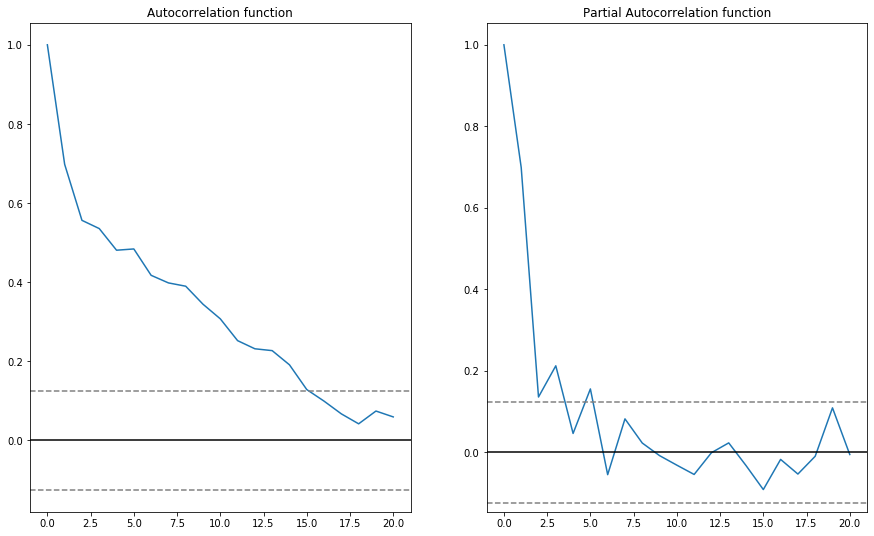

In [19]:
#ACF and PACF
from statsmodels.tsa.stattools import acf,pacf

lag_acf = acf(bang_data_second['Active'].dropna(), nlags = 20)
lag_pacf = pacf(bang_data_second['Active'].dropna(), nlags = 20, method = 'ols')
print("ACF and PACF plots")

# ACF
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y=-1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.axhline(y=1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.title('Autocorrelation function')

# ACF
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y=-1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.axhline(y=1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.title('Partial Autocorrelation function')

ACF and PACF corellograms


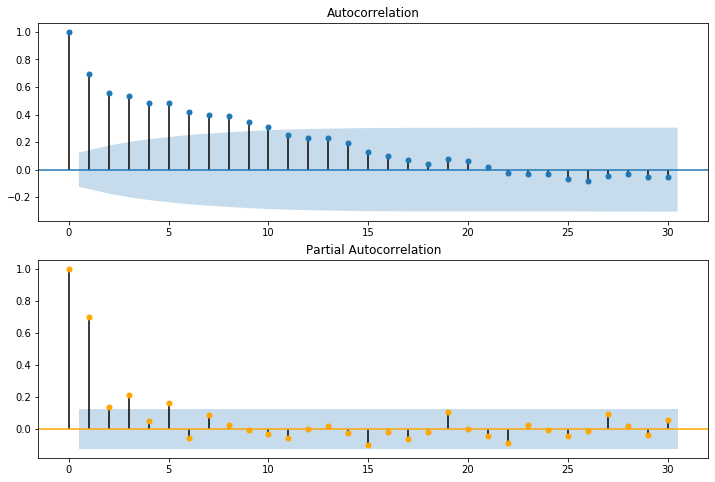

In [20]:
import statsmodels.api as sm

print("ACF and PACF corellograms")
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(bang_data_second['Active'].dropna(),lags = 30, ax = ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(bang_data_second['Active'].dropna(),lags = 30, color='orange', ax = ax2)

# ARIMA model forecasts 

AR model
MSE :  6.322705206718002


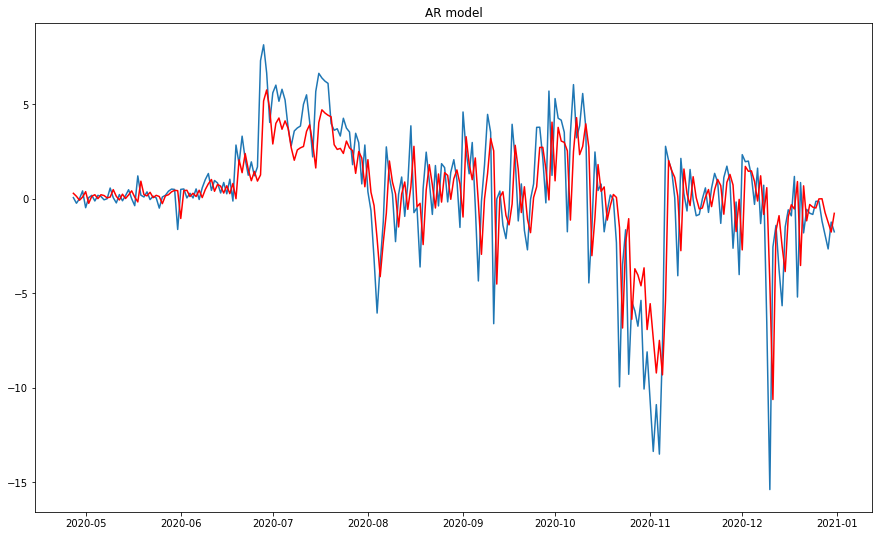

In [21]:
from statsmodels.tsa.arima_model import ARIMA

print("AR model")
model = ARIMA(bang_data_sqrt,order = (1,1,0))
res_AR = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_AR.fittedvalues, color = 'red')
plt.title('AR model')
mse = 1/len(bang_data_sqrt)*sum((res_AR.fittedvalues-bang_data_second['Active'].dropna())**2)
print('MSE : ',mse)

MA model
7.324955313825402


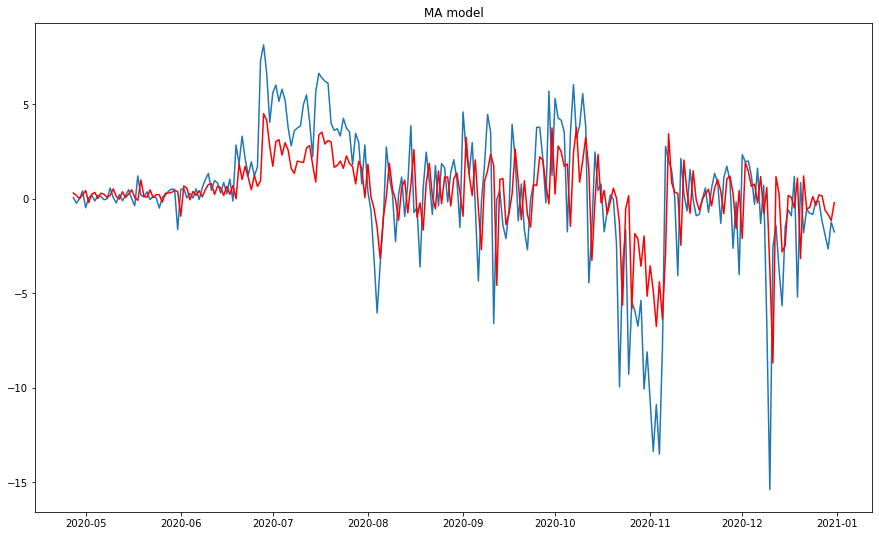

In [22]:
print("MA model")
model = ARIMA(bang_data_sqrt,order = (0,1,2))
res_MA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_MA.fittedvalues, color = 'red')
plt.title('MA model')
mse = 1/len(bang_data_sqrt)*sum((res_MA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

ARIMA model
5.860951993438749


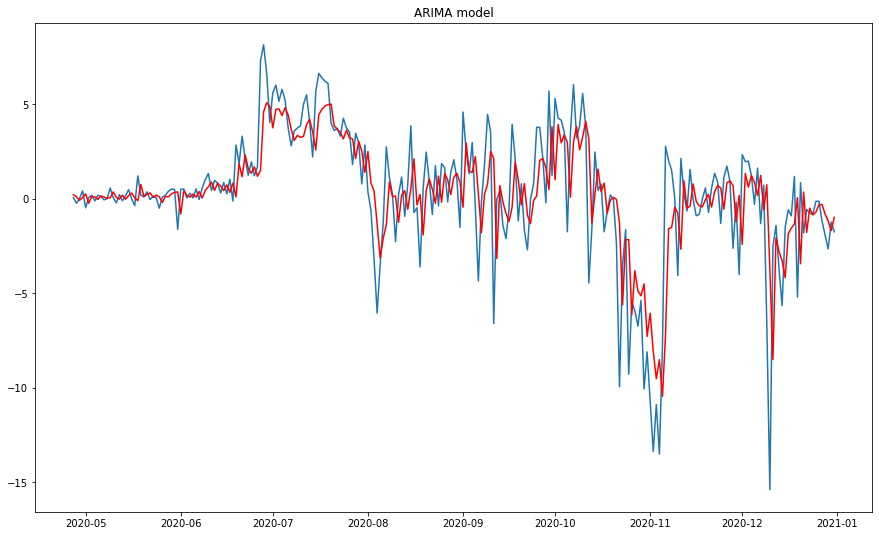

In [23]:
print("ARIMA model")
model = ARIMA(bang_data_sqrt,order = (1,1,2))
res_ARIMA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_ARIMA.fittedvalues, color = 'red')
plt.title('ARIMA model')
mse = 1/len(bang_data_sqrt)*sum((res_ARIMA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

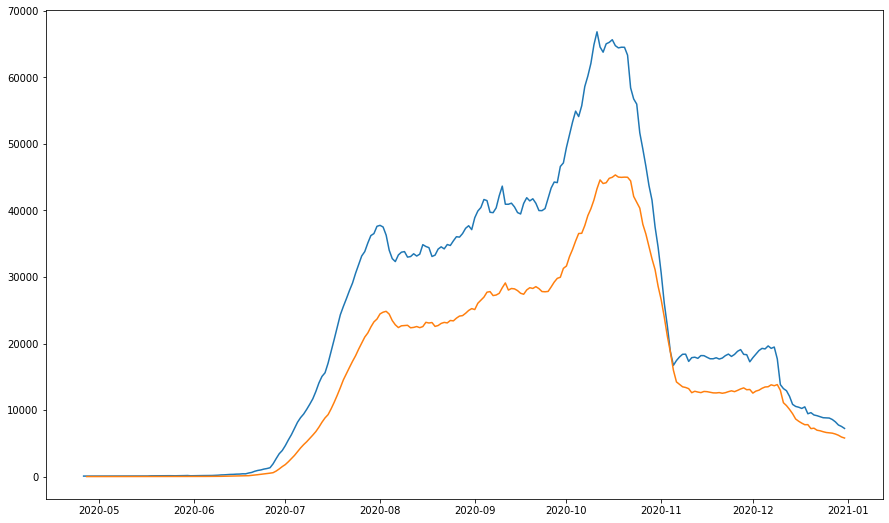

In [24]:
pred_arima = pd.Series(res_ARIMA.fittedvalues, copy=True)
pred_arima = pred_arima.cumsum()
pred_fin = (pred_arima**2)
plt.plot(bang_data)
plt.plot(pred_fin)

In [25]:
def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [26]:
rmse_for_tab = []
for i in range(1,15):
    period = int(i)
    r = res_ARIMA.forecast(steps=period)
    ress = r[0]**2
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)

In [27]:
eval_matrix = pd.DataFrame(columns=['Time frame','Date','All data'])

In [28]:
tim = []

print("Confidence Interval of forecast over 1st test interval")
for i in range(len(rmse_for_tab)):
    tim.append((i+1))
eval_matrix['Time frame'] = tim
eval_matrix['Date'] = bang_data_21.index[:14]
eval_matrix['All data'] = rmse_for_tab
eval_matrix.set_index('Time frame',inplace=True)
eval_matrix

Confidence Interval of forecast over 1st test interval


,Date,All data
Time frame,,
1,2021-01-01,98.679496
2,2021-01-02,97.844535
3,2021-01-03,95.678708
4,2021-01-04,95.901320
5,2021-01-05,96.113377
6,2021-01-06,94.866129
7,2021-01-07,94.342700
8,2021-01-08,94.663586
9,2021-01-09,94.968770


Forecast of trend of growth of COVID-19 for the 1st test interval
               Forecast  Daily forecast  Confidence interval  Actual  Daily
Date                                                                       
2021-01-01  6992.429113            -242            98.679496    7086   -148
2021-01-02  6800.194551            -192            97.844535    6965   -121
2021-01-03  6626.030575            -174            95.678708    7123    158
2021-01-04  6468.282837            -158            95.901320    6692   -431
2021-01-05  6325.468661            -143            96.113377    6148   -544
2021-01-06  6196.257359            -129            94.866129    5680   -468
2021-01-07  6079.452971            -117            94.342700    5623    -57
2021-01-08  5973.979102            -106            94.663586    5860    237
2021-01-09  5878.865600             -95            94.968770    5877     17
2021-01-10  5793.236843             -85            95.015367    6069    192
2021-01-11  5716.30141

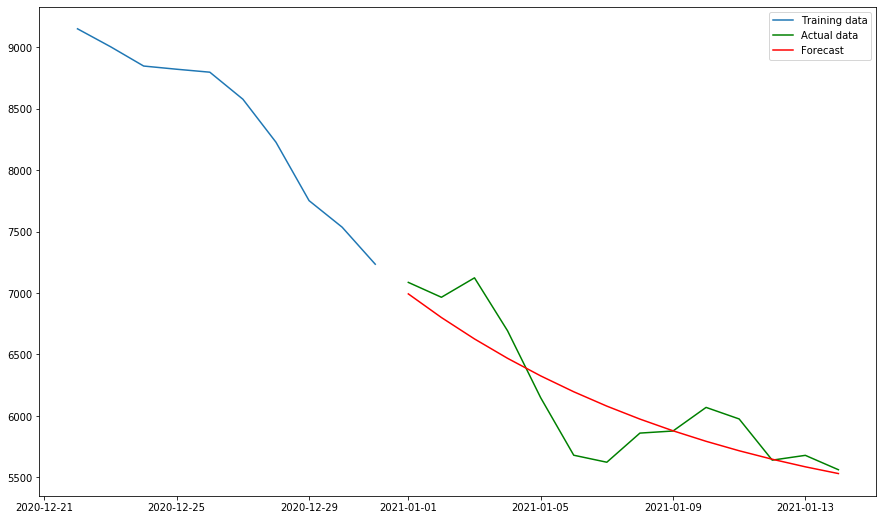

In [29]:
dt = bang_data.index[-1]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
print("Forecast of trend of growth of COVID-19 for the 1st test interval")
daily = []
tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress
daily.append(int(ress[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab
tst['Actual'] = bang_data_21.values[:len(ress)]
cum = bang_data_21.values
daily = []
daily.append(int(cum[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(cum[i])-int(cum[i-1]))
tst['Daily'] = daily
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(bang_data[-10:])
plt.plot(bang_data_21[:len(ress)],color='green')
plt.plot(tst['Forecast'],color='red')
plt.legend(['Training data','Actual data','Forecast'])

# Forecasts over 2nd test interval

(2.273756846138019, 0.9989379039670357, 13, 386, {'1%': -3.447405233596701, '5%': -2.8690569369014605, '10%': -2.5707743450830893}, 7039.684195693106)
Non stationary


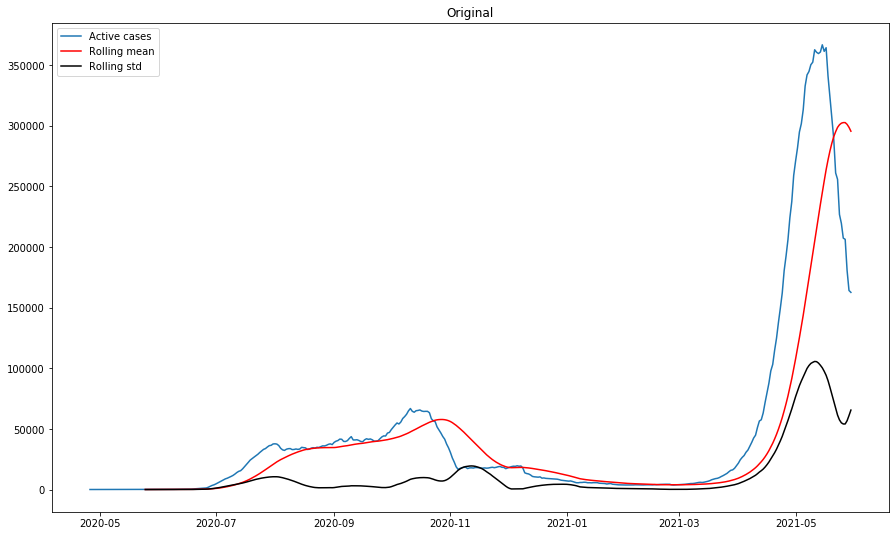

In [30]:
all_data = pd.concat([bang_data,bang_data_21])
rolmean = all_data.rolling(window=30).mean()
rolstd = all_data.rolling(window=30).std()
org = plt.plot(all_data, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Original')

adftst = adfuller(all_data['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

(-4.320242148741941, 0.00040969323478826157, 11, 387, {'1%': -3.447360865754795, '5%': -2.8690374364690445, '10%': -2.5707639493486636}, 1981.8886079264266)
Stationary


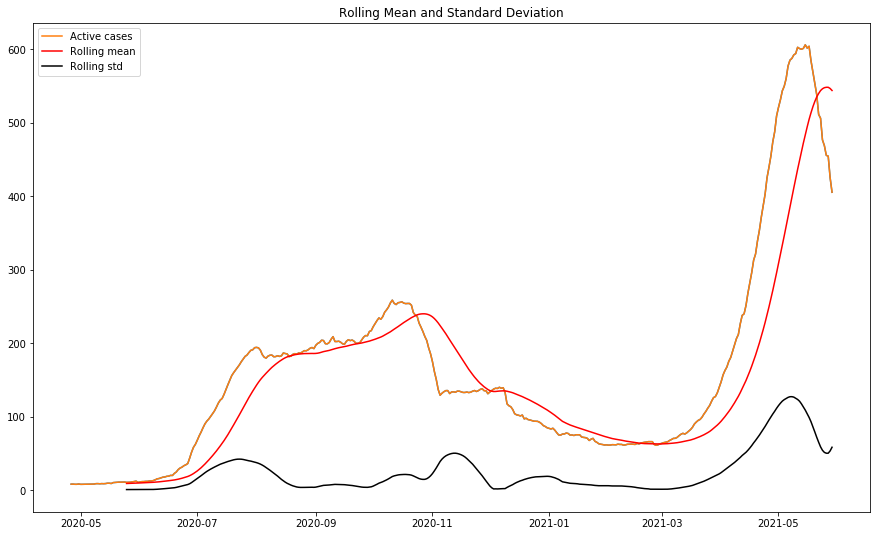

In [31]:
# Sqrt to fix non-stationarity
bang_data_sqrt = np.sqrt(all_data[:-1])
plt.plot(bang_data_sqrt)

rolmean = bang_data_sqrt.rolling(window=30).mean()
rolstd = bang_data_sqrt.rolling(window=30).std()
org = plt.plot(bang_data_sqrt, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_sqrt['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

(-3.76843762438218, 0.003247259653986819, 17, 380, {'1%': -3.4476763783532585, '5%': -2.869176103659426, '10%': -2.570837873961219}, 1984.864618106311)
Stationary


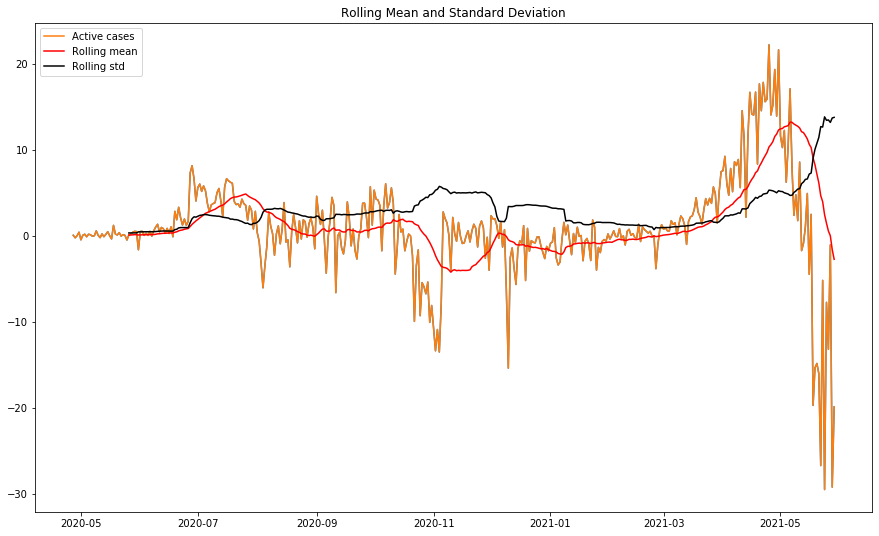

In [32]:
# Differencing method
bang_data_second = bang_data_sqrt.diff(1)
bang_data_second = bang_data_second.dropna()
plt.plot(bang_data_second)

rolmean = bang_data_second.rolling(window=30).mean()
rolstd = bang_data_second.rolling(window=30).std()
org = plt.plot(bang_data_second, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_second['Active'].dropna(), autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

In [33]:
step_fit = auto_arima(bang_data_second['Active'].dropna(), trace = True)
step_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2087.083, Time=0.25 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2541.792, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2213.673, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=2392.276, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2551.123, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=2106.965, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=2106.441, Time=0.13 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=2087.842, Time=0.35 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=2087.064, Time=0.34 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=2108.657, Time=0.15 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=2086.785, Time=0.49 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=2074.555, Time=0.63 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=2084.846, Time=0.36 sec
 ARIMA(5,0,3)(0,0,0)[0] intercept   : AIC=2075.536, Time=0.79 sec
 ARIMA(4,0,4)(0,0,0)[0] intercept

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  398
Model:               SARIMAX(4, 0, 3)   Log Likelihood               -1028.257
Date:                Wed, 02 Jun 2021   AIC                           2072.514
Time:                        13:30:11   BIC                           2104.406
Sample:                             0   HQIC                          2085.146
                                - 398                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8797      0.065    -13.573      0.000      -1.007      -0.753
ar.L2          0.9403      0.075     12.490      0.000       0.793       1.088
ar.L3          0.8441      0.060     13.991      0.000       0.726       0.962
ar.L4          0.0117      0.069      0.169      0.866      -0.124       0.148
ma.L1          1.3107      0.063     20.915      0.000       1.188       1.434
ma.L2         -0.1419      0.094     -1.512      0.130      -0.326       0.042
ma.L3         -0.5100      0.056     -9.076      0.000      -0.620      -0.400
sigma2        10.1433      0.422     24.022      0.000       9.316      10.971
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               585.69
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               6.74   Skew:                            -1.16
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

11.288962375559155


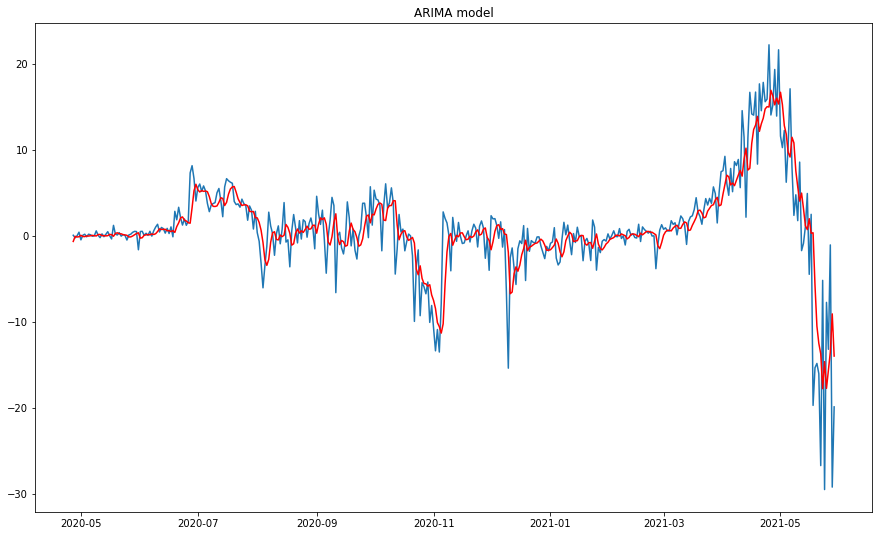

In [34]:
model = ARIMA(bang_data_sqrt,order = (1,1,2))
res_ARIMA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_ARIMA.fittedvalues, color = 'red')
plt.title('ARIMA model')
mse = 1/len(bang_data_sqrt)*sum((res_ARIMA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

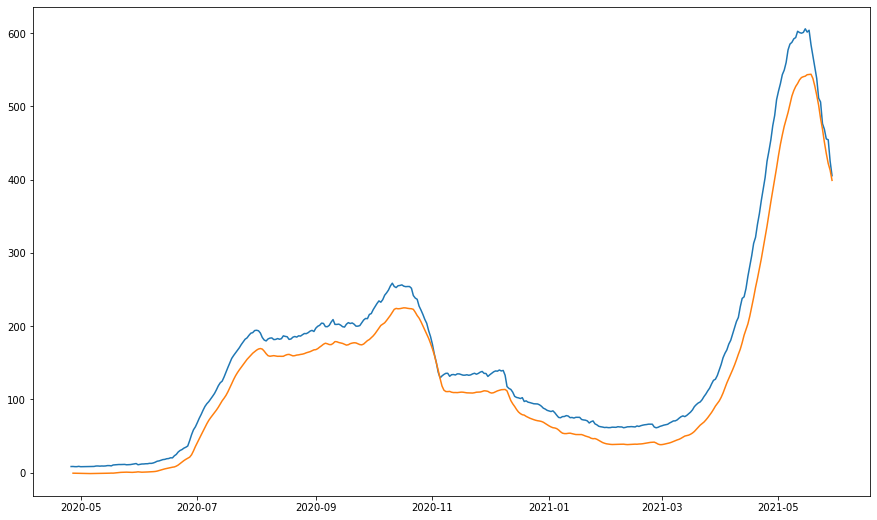

In [35]:
pred_arima = pd.Series(res_ARIMA.fittedvalues, copy=True)
pred_arima = pred_arima.cumsum()
plt.plot(bang_data_sqrt)
plt.plot(pred_arima)

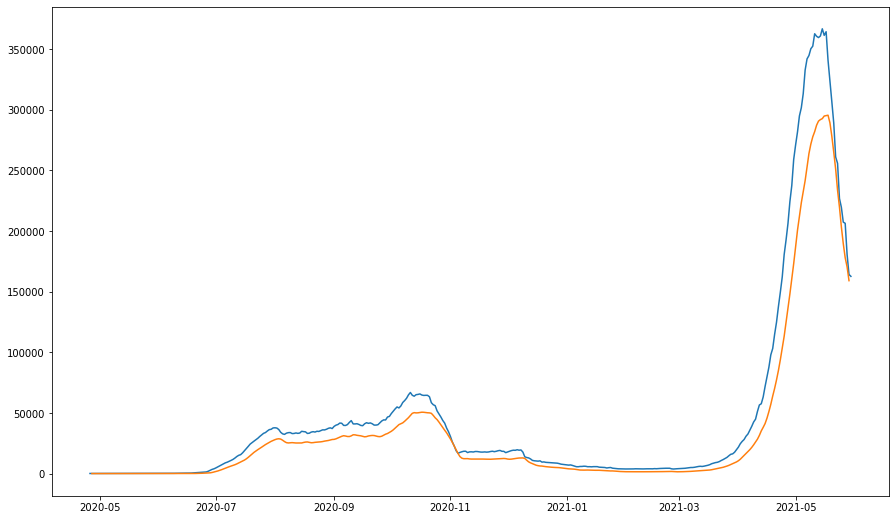

In [36]:
pred_fin = (pred_arima**2)
plt.plot(all_data)
plt.plot(pred_fin)

In [37]:
r = res_ARIMA.forecast(steps=14)
ress = r[0]**2
print(ress)

[150396.35339821 137116.40320794 124751.48807295 113250.56839695
 102565.27783101  92649.78689225  83460.67346142  74956.79981403
  67099.19585709  59850.94826012  53177.09518423  47044.52632854
  41421.88802664  36279.49313963]


            Daily         Active  Confidence Interval
Date                                                 
2021-05-30 -12230  150396.353398            98.679496
2021-05-31 -13280  137116.403208            97.844535
2021-06-01 -12365  124751.488073            95.678708
2021-06-02 -11501  113250.568397            95.901320
2021-06-03 -10685  102565.277831            96.113377
2021-06-04  -9916   92649.786892            94.866129
2021-06-05  -9189   83460.673461            94.342700
2021-06-06  -8504   74956.799814            94.663586


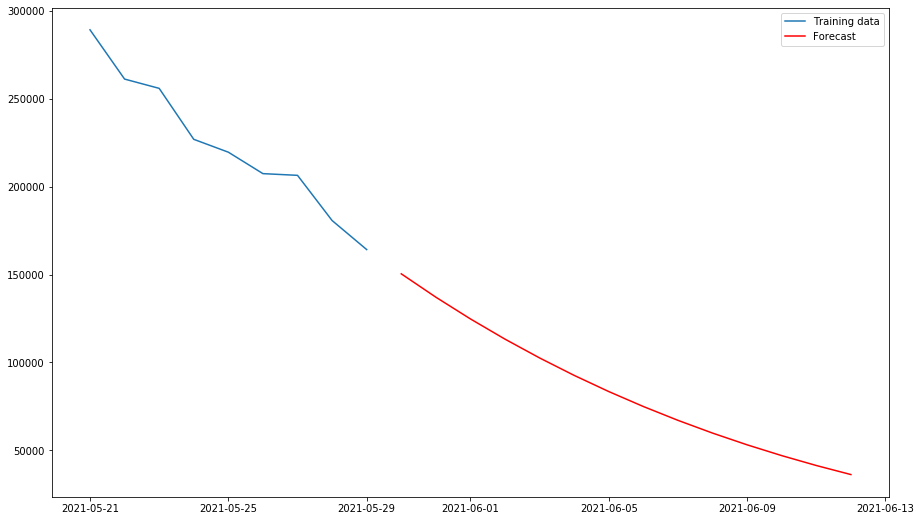

In [38]:
dt = all_data.index[-1]
end = dt + datetime.timedelta(days=len(ress))
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
tst = pd.DataFrame()
tst['Date'] = dtframe
daily = []
daily.append(int(ress[0])-int(all_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily'] = daily
tst['Active'] = ress
tst['Confidence Interval'] = rmse_for_tab[:len(ress)]
tst.set_index('Date',inplace=True)
print(tst[:8])
plt.plot(all_data[-10:-1])
plt.plot(tst['Active'],color='red')
plt.legend(['Training data','Forecast'])

In [73]:
r = res_ARIMA.forecast(steps=30)
ress = r[0]**2
lst = bang_data_21.values
sm = 0
l = min(len(bang_data_21),len(ress))
for i in range(l):
    x = (ress[i]-lst[i])**2
    sm = sm + x
rmse = math.sqrt(sm/l)
print('RMSE:',rmse)

RMSE: 183200.0481788105


In [74]:
r = res_ARIMA.forecast(steps=15)
ress = r[0]**2
lst = bang_data_21.values
sm = 0
l = min(len(bang_data_21),len(ress))
for i in range(l):
    x = (ress[i]-lst[i])**2
    sm = sm + x
rmse = math.sqrt(sm/l)
print('RMSE:',rmse)

RMSE: 222415.3722658177


In [52]:
r = res_ARIMA.forecast(steps=7)
ress = r[0]**2
lst = bang_data_21.values
sm = 0
l = min(len(bang_data_21),len(ress))
for i in range(l):
    x = (ress[i]-lst[i])**2
    sm = sm + x
rmse = math.sqrt(sm/l)
print('RMSE:',rmse)

RMSE: 346.2679445242027


In [53]:
r = res_ARIMA.forecast(steps=4)
ress = r[0]**2
lst = bang_data_21.values
sm = 0
l = min(len(bang_data_21),len(ress))
for i in range(l):
    x = (ress[i]-lst[i])**2
    sm = sm + x
rmse = math.sqrt(sm/l)
print('RMSE:',rmse)

RMSE: 288.5066399230101


In [41]:
print(district_data_21['Udupi'])

                State District Confirmed Recovered Deceased  Active
Date                                                               
2021-01-01  Karnataka    Udupi     23073     22802      188      83
2021-01-02  Karnataka    Udupi     23085     22815      188      82
2021-01-03  Karnataka    Udupi     23104     22819      188      97
2021-01-04  Karnataka    Udupi     23113     22833      189      91
2021-01-05  Karnataka    Udupi     23139     22840      189     110
...               ...      ...       ...       ...      ...     ...
2021-04-26  Karnataka    Udupi     29173     27291      194    1688
2021-04-27  Karnataka    Udupi     29650     27563      194    1893
2021-04-28  Karnataka    Udupi     30314     27889      194    2231
2021-04-29  Karnataka    Udupi     30882     28328      196    2358
2021-04-30  Karnataka    Udupi     31542     28687      198    2657

[120 rows x 6 columns]
